<a href="https://colab.research.google.com/github/Pranavi-06git/music-recommender-ml/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("sales_data.csv")

In [ ]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [ ]:
df['day'] = df['Sale_Date'].dt.day
df['month'] = df['Sale_Date'].dt.month
df['weekday'] = df['Sale_Date'].dt.weekday

In [ ]:
df = df[['Sales_Amount', 'Quantity_Sold', 'Unit_Price', 'Discount',
         'day', 'month', 'weekday',
         'Product_Category', 'Sales_Channel', 'Region']]

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Sales_Amount', axis=1)
y = df['Sales_Amount']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 2478.1764786110434


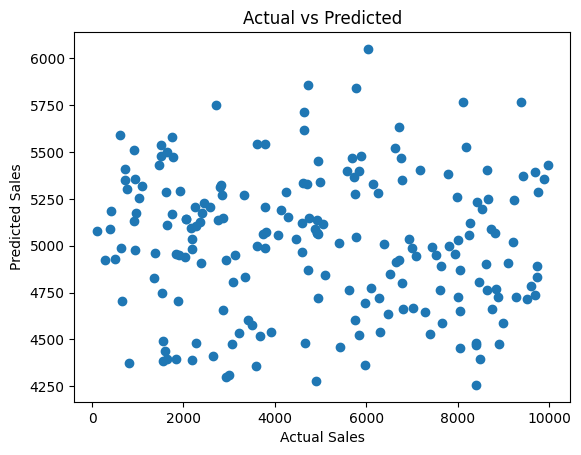

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

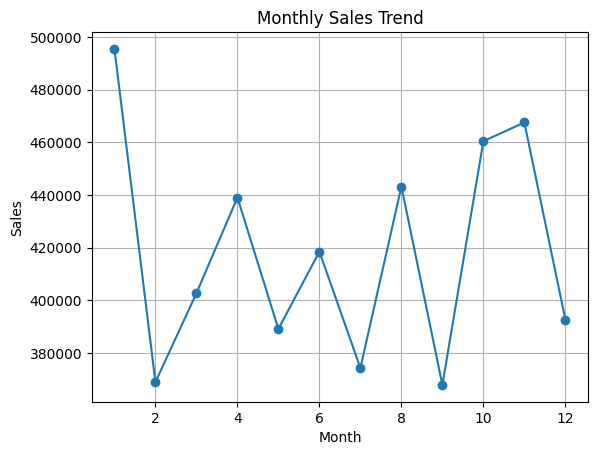

In [ ]:
monthly_sales = df.groupby('month')['Sales_Amount'].sum()


plt.figure()
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()



In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 2478.1764786110434


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 8173792.899328183


In [ ]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 2858.9845923558564


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.03461214334298779
